# Act2 - Policy Gradients

- Pedro Mauri Mtz - A01029143

Policy Gradients implementation in a simple MiniGrid environment.

Goal: Get to the target (Red square)

## Imports

In [1]:
from minigrid.core.grid import Grid
from minigrid.core.mission import MissionSpace
from minigrid.core.world_object import Goal, Key, Wall, Lava, Floor
from minigrid.manual_control import ManualControl
from minigrid.minigrid_env import MiniGridEnv

from minigrid.core.actions import Actions
from scipy.special import softmax

import matplotlib.pyplot as plt
import numpy as np
import random

## Environment

In [2]:
class SimpleEnv(MiniGridEnv):

    def __init__(
        self,
        size = 19,
        max_steps: int | None = None,
        **kwargs,
    ):

        self.size = size
        self.key_positions = []
        self.lava_positions = []

        self.start_agent_pos = (1, 1)

        mission_space = MissionSpace(mission_func = self._gen_mission)

        if max_steps is None:
            max_steps = 4 * size ** 2

        super().__init__(
            mission_space = mission_space,
            grid_size = size,
            see_through_walls = True,
            max_steps = max_steps,
            **kwargs,
        )

    @staticmethod
    def _gen_mission():
        return "Reach the goal - Policy Gradients"

    def _gen_grid(self, width, height):

        self.grid = Grid(width, height)
        self.grid.wall_rect(0, 0, width, height)

        # Place a goal square in the bottom-right corner
        self.goal_pos = (width - 2, height - 2)
        self.put_obj(Goal(), *self.goal_pos)

        self._place_agent()

        self.mission = "Reach the goal - Policy Gradients"

    def _place_agent(self):
        while True:
            x = random.randint(1, self.size - 2)
            y = random.randint(1, self.size - 2)

            pos = (x, y)

            # Check if the position is empty (not wall, lava, floor, or goal)
            if (self.grid.get(*pos) is None and pos != self.goal_pos):
                self.agent_pos = pos
                self.agent_dir = random.randint(0, 3)  # Random direction
                break

    def reset(self, **kwargs):
        out = super().reset(**kwargs)
        return out

    def step(self, action):
        prev_pos = self.agent_pos
        prev_dir = self.agent_dir

        obs, reward, terminated, truncated, info = super().step(action)

        # Get manhattan distance to goal
        prev_dist = abs(prev_pos[0] - self.goal_pos[0]) + abs(prev_pos[1] - self.goal_pos[1])
        new_dist  = abs(self.agent_pos[0] - self.goal_pos[0]) + abs(self.agent_pos[1] - self.goal_pos[1])

        # Reward shaping based on distance to goal
        if new_dist < prev_dist:
            reward += 0.2

        # Small step penalty
        reward -= 0.01

        # Turning without moving penalty:
        if action == Actions.left or action == Actions.right:
            reward -= 0.05

        # Obstacle penalty:
        if (prev_dir == self.agent_dir and prev_pos == self.agent_pos):
            reward -= 0.3

        # Goal reward
        if isinstance(self.grid.get(*self.agent_pos), Goal):
            reward += 10.0
            terminated = True

        return obs, reward, terminated, truncated, info

## Policy Gradients Agent Implementation

In [3]:
class PolicyGradientAgent:
    # Constructor:
    def __init__(self, env, lr = 0.05, gamma = 0.99, baseline_lr = 0.01):
        self.env = env
        self.lr = lr
        self.gamma = gamma
        self.baseline_lr = baseline_lr
        self.baseline = 0.0

        self.logits = {}  # state -> np.array of shape (n_actions,)
        self.n_actions = 3 # (Turn left, Turn right, Move forward)

    # Get current state (Pos, Dir):
    def get_state(self):
        x, y = self.env.agent_pos
        d = self.env.agent_dir
        return (x, y, d)

    # Initialize state in the logits table
    def init_state(self, state):
        if state not in self.logits:
            self.logits[state] = np.zeros(self.n_actions, dtype = np.float32)

    # Sample an action from the current policy (softmax over logits)
    def choose_action(self, state, exploit_only = False):
        self.init_state(state)
        probs = softmax(self.logits[state])

        if exploit_only:
            # Demo mode: act (near-)greedily w.r.t. the learned policy
            max_p = np.max(probs)
            best_actions_idxs = np.flatnonzero(probs == max_p)
            return int(random.choice(best_actions_idxs))

        return int(np.random.choice(self.n_actions, p = probs))

    # Compute discounted returns G_t for a full episode (backward pass)
    def compute_returns(self, rewards):
        returns = np.zeros(len(rewards), dtype = np.float32)
        running_return = 0.0

        for t in reversed(range(len(rewards))):
            running_return = rewards[t] + self.gamma * running_return
            returns[t] = running_return

        return returns

    # Update the policy at the end of an episode using REINFORCE with baseline
    def update_episode(self, states, actions, rewards):
        returns = self.compute_returns(rewards)

        for state, action, G_t in zip(states, actions, returns):
            # Update the moving-average baseline (reduces variance, as in Class 4)
            self.baseline += self.baseline_lr * (G_t - self.baseline)
            advantage = G_t - self.baseline

            self.init_state(state)
            probs = softmax(self.logits[state])

            grad = np.zeros(self.n_actions, dtype = np.float32)
            grad[action] = 1.0
            grad -= probs

            self.logits[state] += self.lr * grad * advantage

## Reinforcement Learning Training Loop

In [4]:
def _safe_reset(env):
    out = env.reset()

    if isinstance(out, tuple):
        obs, info = out
        return obs
    else:
        return out


def train_policy_gradient(env, agent, epochs, max_steps_per_epoch):
    epoch_rewards = []

    for epoch in range(epochs):

        obs = _safe_reset(env)
        total_reward = 0.0

        states, actions, rewards = [], [], []

        for step in range(max_steps_per_epoch):

            state = agent.get_state()
            action = agent.choose_action(state, exploit_only = False)

            obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            total_reward += reward

            states.append(state)
            actions.append(action)
            rewards.append(reward)

            if done:
                break

        # Monte Carlo update: learn from the full episode trajectory
        agent.update_episode(states, actions, rewards)

        epoch_rewards.append(total_reward)

        if (epoch + 1) % 100 == 0:
            print(f"[Train] Epoch {epoch + 1}/{epochs}, Total Reward: {total_reward:.2f}, Baseline: {agent.baseline:.3f}")

    return epoch_rewards

## Implementation of Demonstration of learned policy (Testing)

In [5]:
def demo_policy(env, agent, epochs, max_steps_per_epoch, render_mode):

    env.render_mode = render_mode

    for epoch in range(epochs):

        print(f"[Demo] Epoch {epoch + 1}/{epochs}")

        _ = _safe_reset(env)

        total_reward = 0.0

        if render_mode == 'human':
            env.render()

        for t in range(max_steps_per_epoch):
            state = agent.get_state()

            action = agent.choose_action(state, exploit_only = True)

            obs, reward, terminated, truncated, info = env.step(action)
            total_reward += reward

            if render_mode == 'human':
                env.render()

            if terminated or truncated:
                break

## Training

In [6]:
# Create Training environment
train_env = SimpleEnv(render_mode = None)

# Create Policy Gradient agent
agent = PolicyGradientAgent(train_env,
                                lr = 0.05,
                                gamma = 0.99,
                                baseline_lr = 0.01
                                )

# Train the agent
rewards = train_policy_gradient(train_env,
                                    agent,
                                    epochs = 10000,
                                    max_steps_per_epoch = 200
                                    )

train_env.close()

[Train] Epoch 100/10000, Total Reward: -2.60, Baseline: -0.601
[Train] Epoch 200/10000, Total Reward: 12.66, Baseline: 5.914
[Train] Epoch 300/10000, Total Reward: -5.05, Baseline: 0.461
[Train] Epoch 400/10000, Total Reward: 11.96, Baseline: 3.278
[Train] Epoch 500/10000, Total Reward: -2.50, Baseline: 0.831
[Train] Epoch 600/10000, Total Reward: 12.76, Baseline: 8.804
[Train] Epoch 700/10000, Total Reward: 12.49, Baseline: 7.489
[Train] Epoch 800/10000, Total Reward: 15.26, Baseline: 9.501
[Train] Epoch 900/10000, Total Reward: 11.32, Baseline: 9.579
[Train] Epoch 1000/10000, Total Reward: 14.43, Baseline: 10.250
[Train] Epoch 1100/10000, Total Reward: 11.52, Baseline: 9.947
[Train] Epoch 1200/10000, Total Reward: 13.31, Baseline: 10.229
[Train] Epoch 1300/10000, Total Reward: 12.83, Baseline: 10.875
[Train] Epoch 1400/10000, Total Reward: 13.53, Baseline: 11.023
[Train] Epoch 1500/10000, Total Reward: 13.43, Baseline: 10.181
[Train] Epoch 1600/10000, Total Reward: 15.05, Baseline: 1

## Demonstration (Testing)

In [7]:
# Create demo environment
demo_env = SimpleEnv(render_mode = 'human')

# Update agent's environment to env for demo
agent.env = demo_env

# Demo the learned policy
demo_policy(demo_env,
            agent,
            epochs = 10,
            max_steps_per_epoch = 60,
            render_mode = 'human'
            )

demo_env.close()

[Demo] Epoch 1/10


c:\Users\pedro\Documents\Documentos Tec\Semestre_7_Concentracion_IA\Advanced_IA_Implementation\env\Lib\site-packages\pygame\sysfont.py:500: UserWarning: The system font 'freesansbold.ttf' couldn't be found. Did you mean: 'freesansbold', 'freesans'? Verify your font name input. Using the default font instead.
  warnings.warn(


[Demo] Epoch 2/10
[Demo] Epoch 3/10
[Demo] Epoch 4/10
[Demo] Epoch 5/10
[Demo] Epoch 6/10
[Demo] Epoch 7/10
[Demo] Epoch 8/10
[Demo] Epoch 9/10
[Demo] Epoch 10/10


## Learning Curve

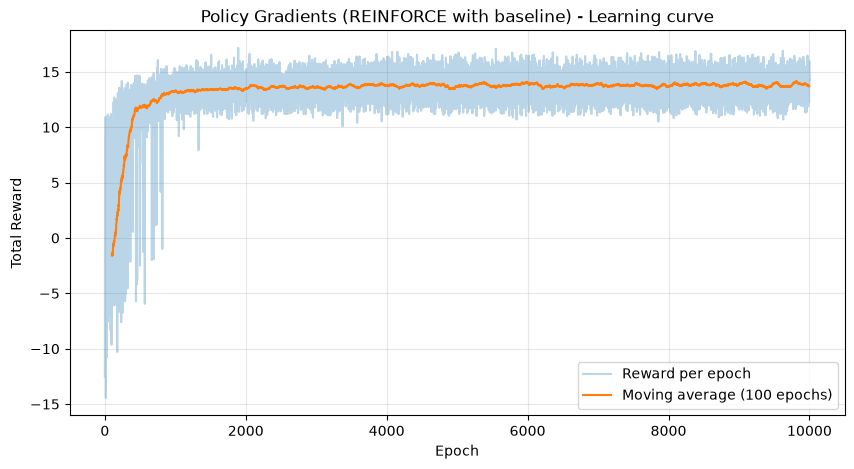

In [8]:
rewards_arr = np.array(rewards)
window = 100

# Moving average to smooth the noise from sampling actions from the policy
moving_avg = np.convolve(rewards_arr, np.ones(window) / window, mode = 'valid')

plt.figure(figsize = (10, 5))
plt.plot(rewards_arr, alpha = 0.3, label = "Reward per epoch")
plt.plot(range(window - 1, len(rewards_arr)), moving_avg, label = f"Moving average ({window} epochs)")
plt.xlabel("Epoch")
plt.ylabel("Total Reward")
plt.title("Policy Gradients (REINFORCE with baseline) - Learning curve")
plt.legend()
plt.grid(alpha = 0.3)
plt.show()